In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_colwidth", 120)

In [2]:
df = pd.read_csv("disney_plus_titles.csv")
print("Shape:", df.shape)
df.head()

Shape: (1450, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Duck the Halls: A Mickey Mouse Christmas Special,"Alonso Ramirez Ramos, Dave Wasson","Chris Diamantopoulos, Tony Anselmo, Tress MacNeille, Bill Farmer, Russi Taylor, Corey Burton",NaN,26-Nov-21,2016,TV-G,23 min,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,s2,Movie,Ernest Saves Christmas,John Cherry,"Jim Varney, Noelle Parker, Douglas Seale",NaN,26-Nov-21,1988,PG,91 min,Comedy,Santa Claus passes his magic bag to a new St. Nic.
2,s3,Movie,Ice Age: A Mammoth Christmas,Karen Disher,"Raymond Albert Romano, John Leguizamo, Denis Leary, Queen Latifah",United States,26-Nov-21,2011,TV-G,23 min,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,s4,Movie,The Queen Family Singalong,Hamish Hamilton,"Darren Criss, Adam Lambert, Derek Hough, Alexander Jean, Fall Out Boy, Jimmie Allen",NaN,26-Nov-21,2021,TV-PG,41 min,Musical,"This is real life, not just fantasy!"
4,s5,TV Show,The Beatles: Get Back,NaN,"John Lennon, Paul McCartney, George Harrison, Ringo Starr",NaN,25-Nov-21,2021,NaN,1 Season,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson capturing a moment in music history with The Beatles.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       1450 non-null   str  
 1   type          1450 non-null   str  
 2   title         1450 non-null   str  
 3   director      977 non-null    str  
 4   cast          1260 non-null   str  
 5   country       1231 non-null   str  
 6   date_added    1447 non-null   str  
 7   release_year  1450 non-null   int64
 8   rating        1447 non-null   str  
 9   duration      1450 non-null   str  
 10  listed_in     1450 non-null   str  
 11  description   1450 non-null   str  
dtypes: int64(1), str(11)
memory usage: 136.1 KB


In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing

director        473
country         219
cast            190
date_added        3
rating            3
title             0
show_id           0
type              0
release_year      0
duration          0
listed_in         0
description       0
dtype: int64

In [5]:
query_titles = [
    "Frozen",
    "Marvel Studios' The Avengers",
    "The Mandalorian",
]

df[df["title"].isin(query_titles)][["title", "type", "listed_in", "rating", "release_year"]]

,title,type,listed_in,rating,release_year
377,The Mandalorian,TV Show,"Action-Adventure, Family, Science Fiction",TV-14,2019
903,Frozen,Movie,"Animation, Family, Fantasy",PG,2013
1050,Marvel Studios' The Avengers,Movie,"Action-Adventure, Fantasy, Science Fiction",PG-13,2012


In [6]:
data = df[["title", "type", "rating", "release_year", "listed_in", "description"]].copy()

data["type"] = data["type"].fillna("Unknown")
data["rating"] = data["rating"].fillna("Unknown")
data["listed_in"] = data["listed_in"].fillna("Unknown")
data["description"] = data["description"].fillna("")
data["release_year"] = pd.to_numeric(data["release_year"], errors="coerce")

data = data.dropna(subset=["title", "release_year"]).copy()

before = len(data)
data = data.drop_duplicates(subset=["title"], keep="first").reset_index(drop=True)
after = len(data)

print(f"Rows before dropping duplicate titles: {before}")
print(f"Rows after dropping duplicate titles:  {after}")
data.head()

Rows before dropping duplicate titles: 1450
Rows after dropping duplicate titles:  1450


,title,type,rating,release_year,listed_in,description
0,Duck the Halls: A Mickey Mouse Christmas Special,Movie,TV-G,2016,"Animation, Family",Join Mickey and the gang as they duck the halls!
1,Ernest Saves Christmas,Movie,PG,1988,Comedy,Santa Claus passes his magic bag to a new St. Nic.
2,Ice Age: A Mammoth Christmas,Movie,TV-G,2011,"Animation, Comedy, Family",Sid the Sloth is on Santa's naughty list.
3,The Queen Family Singalong,Movie,TV-PG,2021,Musical,"This is real life, not just fantasy!"
4,The Beatles: Get Back,TV Show,Unknown,2021,"Docuseries, Historical, Music",A three-part documentary from Peter Jackson capturing a moment in music history with The Beatles.


In [7]:
data["genre_list"] = data["listed_in"].apply(
    lambda x: [genre.strip() for genre in str(x).split(",")]
)

data[["title", "listed_in", "genre_list"]].head()

,title,listed_in,genre_list
0,Duck the Halls: A Mickey Mouse Christmas Special,"Animation, Family","[Animation, Family]"
1,Ernest Saves Christmas,Comedy,[Comedy]
2,Ice Age: A Mammoth Christmas,"Animation, Comedy, Family","[Animation, Comedy, Family]"
3,The Queen Family Singalong,Musical,[Musical]
4,The Beatles: Get Back,"Docuseries, Historical, Music","[Docuseries, Historical, Music]"


In [8]:
data["type"].value_counts()

type
Movie      1052
TV Show     398
Name: count, dtype: int64

In [9]:
genre_counts = (
    data["genre_list"]
    .explode()
    .value_counts()
    .head(15)
)

genre_counts

genre_list
Family              632
Animation           542
Comedy              526
Action-Adventure    452
Animals & Nature    208
Coming of Age       205
Fantasy             192
Documentary         174
Kids                141
Drama               134
Docuseries          122
Science Fiction      91
Historical           53
Music                48
Musical              44
Name: count, dtype: int64

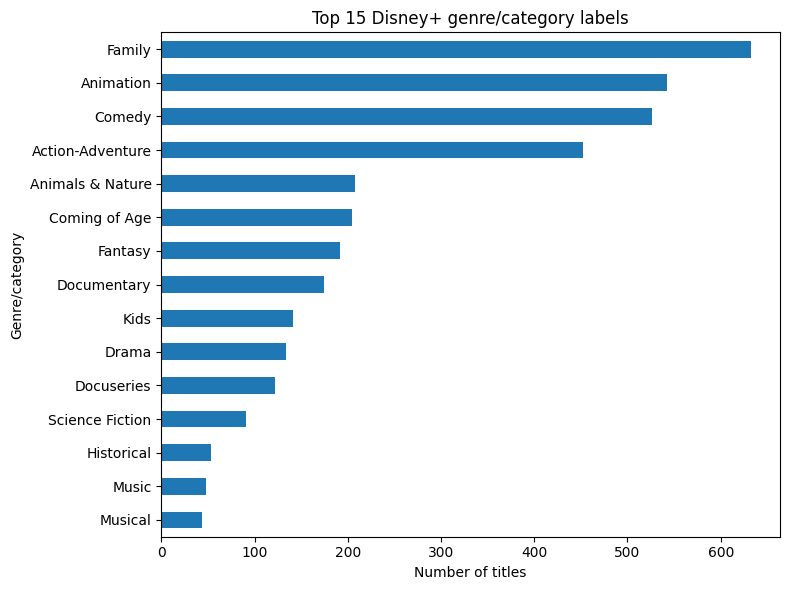

In [10]:
genre_counts.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Disney+ genre/category labels")
plt.xlabel("Number of titles")
plt.ylabel("Genre/category")
plt.tight_layout()
plt.show()

In [11]:
# ----- 1) Genre/category multi-hot encoding -----
all_genres = sorted(set(genre for genres in data["genre_list"] for genre in genres))
genre_to_idx = {genre: i for i, genre in enumerate(all_genres)}

genre_matrix = np.zeros((len(data), len(all_genres)), dtype=int)
for row_idx, genres in enumerate(data["genre_list"]):
    for genre in genres:
        genre_matrix[row_idx, genre_to_idx[genre]] = 1

genre_matrix = csr_matrix(genre_matrix)
print("Genre matrix shape:", genre_matrix.shape)

Genre matrix shape: (1450, 44)


In [12]:
# ----- 2) One-hot encode type and rating -----
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    # Compatibility fallback for older scikit-learn versions
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

cat_matrix = ohe.fit_transform(data[["type", "rating"]])
print("Categorical matrix shape:", cat_matrix.shape)

Categorical matrix shape: (1450, 12)


In [13]:
# ----- 3) Scale release year -----
scaler = StandardScaler()
year_matrix = scaler.fit_transform(data[["release_year"]])
year_matrix = csr_matrix(year_matrix)
print("Year matrix shape:", year_matrix.shape)

Year matrix shape: (1450, 1)


In [14]:
# ----- 4) TF-IDF on description text -----
tfidf = TfidfVectorizer(stop_words="english", max_features=1000)
desc_matrix = tfidf.fit_transform(data["description"])
print("Description TF-IDF matrix shape:", desc_matrix.shape)

Description TF-IDF matrix shape: (1450, 1000)


In [15]:
# ----- 5) Combine all feature blocks -----
X = hstack([genre_matrix, cat_matrix, year_matrix, desc_matrix]).tocsr()
print("Combined feature matrix shape:", X.shape)

Combined feature matrix shape: (1450, 1057)


In [16]:
def get_top_similar_titles(query_title, feature_matrix, metadata_df, top_n=10):
    matches = metadata_df.index[metadata_df["title"] == query_title].tolist()
    if not matches:
        raise ValueError(f"Query title not found: {query_title}")

    query_idx = matches[0]
    query_vector = feature_matrix[query_idx]

    sims = cosine_similarity(query_vector, feature_matrix).flatten()

    # Create a result frame
    results = metadata_df[["title", "type", "listed_in", "rating", "release_year"]].copy()
    results["similarity"] = sims

    # Remove the query title itself and sort descending
    results = results[results["title"] != query_title].sort_values(
        by="similarity", ascending=False
    )

    return results.head(top_n).reset_index(drop=True)

In [17]:
# Example: titles most similar to Frozen
get_top_similar_titles("Frozen", X, data, top_n=10)

,title,type,listed_in,rating,release_year,similarity
0,Coco,Movie,"Animation, Family, Fantasy",PG,2017,0.838852
1,Coco (in Spanish),Movie,"Animation, Family, Fantasy",PG,2017,0.838852
2,Float,Movie,"Animation, Family, Fantasy",PG,2019,0.837311
3,Out,Movie,"Animation, Family, Fantasy",PG,2020,0.836182
4,Tim Burton’s The Nightmare Before Christmas,Movie,"Animation, Family, Fantasy",PG,1993,0.771506
5,Frozen Fever,Movie,"Animation, Family, Fantasy",G,2015,0.742400
6,Loop,Movie,"Animation, Family",PG,2020,0.738138
7,Twenty Something,Movie,"Animation, Family",PG,2021,0.736876
8,Disney's A Christmas Carol,Movie,"Animation, Fantasy",PG,2009,0.734754
9,Frozen 2,Movie,"Action-Adventure, Animation, Family",PG,2019,0.716950


In [18]:
top_frozen = get_top_similar_titles("Frozen", X, data, top_n=10)
top_avengers = get_top_similar_titles("Marvel Studios' The Avengers", X, data, top_n=10)
top_mando = get_top_similar_titles("The Mandalorian", X, data, top_n=10)

In [19]:
print("Top 10 most similar titles to Frozen")
display(top_frozen)

Top 10 most similar titles to Frozen


,title,type,listed_in,rating,release_year,similarity
0,Coco,Movie,"Animation, Family, Fantasy",PG,2017,0.838852
1,Coco (in Spanish),Movie,"Animation, Family, Fantasy",PG,2017,0.838852
2,Float,Movie,"Animation, Family, Fantasy",PG,2019,0.837311
3,Out,Movie,"Animation, Family, Fantasy",PG,2020,0.836182
4,Tim Burton’s The Nightmare Before Christmas,Movie,"Animation, Family, Fantasy",PG,1993,0.771506
5,Frozen Fever,Movie,"Animation, Family, Fantasy",G,2015,0.742400
6,Loop,Movie,"Animation, Family",PG,2020,0.738138
7,Twenty Something,Movie,"Animation, Family",PG,2021,0.736876
8,Disney's A Christmas Carol,Movie,"Animation, Fantasy",PG,2009,0.734754
9,Frozen 2,Movie,"Action-Adventure, Animation, Family",PG,2019,0.716950


In [20]:
print("Top 10 most similar titles to Marvel Studios' The Avengers")
display(top_avengers)

Top 10 most similar titles to Marvel Studios' The Avengers


,title,type,listed_in,rating,release_year,similarity
0,Marvel Studios' Thor: The Dark World,Movie,"Action-Adventure, Fantasy, Science Fiction",PG-13,2013,0.838177
1,Marvel Studios' Avengers: Infinity War,Movie,"Action-Adventure, Fantasy, Science Fiction",PG-13,2018,0.835933
2,Marvel Studios' Avengers: Endgame,Movie,"Action-Adventure, Fantasy, Science Fiction",PG-13,2019,0.834732
3,Star Wars: The Last Jedi (Episode VIII),Movie,"Action-Adventure, Science Fiction",PG-13,2017,0.771784
4,Rogue One: A Star Wars Story,Movie,"Action-Adventure, Science Fiction",PG-13,2016,0.765181
5,Star Wars: The Force Awakens (Episode VII),Movie,"Action-Adventure, Science Fiction",PG-13,2015,0.738774
6,Pirates of the Caribbean: Dead Men Tell No Tales,Movie,"Action-Adventure, Fantasy",PG-13,2017,0.737810
7,Pirates of the Caribbean: On Stranger Tides,Movie,"Action-Adventure, Fantasy",PG-13,2011,0.737363
8,Prince of Persia: The Sands of Time,Movie,"Action-Adventure, Fantasy",PG-13,2010,0.736276
9,Avatar,Movie,"Action-Adventure, Science Fiction",PG-13,2009,0.734886


In [21]:
print("Top 10 most similar titles to The Mandalorian")
display(top_mando)

Top 10 most similar titles to The Mandalorian


,title,type,listed_in,rating,release_year,similarity
0,Race to the Center of the Earth,TV Show,"Action-Adventure, Family, Game Show / Competition",TV-14,2021,0.696411
1,Loki,TV Show,"Action-Adventure, Fantasy, Science Fiction",TV-14,2021,0.696411
2,The Falcon and The Winter Soldier,TV Show,"Action-Adventure, Buddy, Science Fiction",TV-14,2021,0.696411
3,Cosmos: Possible Worlds,TV Show,"Action-Adventure, Docuseries, Family",TV-14,2020,0.695172
4,Marvel's Inhumans,TV Show,"Action-Adventure, Science Fiction, Superhero",TV-14,2017,0.690147
5,Marvel's Agent Carter,TV Show,"Action-Adventure, Science Fiction, Spy/Espionage",TV-14,2014,0.683058
6,The Bad Batch,TV Show,"Action-Adventure, Animation, Science Fiction",TV-PG,2021,0.613098
7,Hawkeye,TV Show,"Action-Adventure, Superhero",TV-14,2021,0.590993
8,The Mysterious Benedict Society,TV Show,"Action-Adventure, Family",TV-PG,2021,0.590993
9,Star Wars: The Clone Wars,TV Show,"Action-Adventure, Animation, Science Fiction",TV-PG,2008,0.545474


In [22]:
top_frozen["query_title"] = "Frozen"
top_avengers["query_title"] = "Marvel Studios' The Avengers"
top_mando["query_title"] = "The Mandalorian"

summary_table = pd.concat([top_frozen, top_avengers, top_mando], ignore_index=True)
summary_table = summary_table[[
    "query_title", "title", "similarity", "type", "listed_in", "rating", "release_year"
]]
summary_table.head(15)

,query_title,title,similarity,type,listed_in,rating,release_year
0,Frozen,Coco,0.838852,Movie,"Animation, Family, Fantasy",PG,2017
1,Frozen,Coco (in Spanish),0.838852,Movie,"Animation, Family, Fantasy",PG,2017
2,Frozen,Float,0.837311,Movie,"Animation, Family, Fantasy",PG,2019
3,Frozen,Out,0.836182,Movie,"Animation, Family, Fantasy",PG,2020
4,Frozen,Tim Burton’s The Nightmare Before Christmas,0.771506,Movie,"Animation, Family, Fantasy",PG,1993
5,Frozen,Frozen Fever,0.742400,Movie,"Animation, Family, Fantasy",G,2015
6,Frozen,Loop,0.738138,Movie,"Animation, Family",PG,2020
7,Frozen,Twenty Something,0.736876,Movie,"Animation, Family",PG,2021
8,Frozen,Disney's A Christmas Carol,0.734754,Movie,"Animation, Fantasy",PG,2009
9,Frozen,Frozen 2,0.716950,Movie,"Action-Adventure, Animation, Family",PG,2019


In [23]:
summary_table.to_csv("disney_similarity_top10_results.csv", index=False)
print("Saved: disney_similarity_top10_results.csv")

Saved: disney_similarity_top10_results.csv


In [24]:
# Validation checks
assert X.shape[0] == len(data), "Feature matrix row count does not match data row count."

for query_title, result_df in [
    ("Frozen", top_frozen),
    ("Marvel Studios' The Avengers", top_avengers),
    ("The Mandalorian", top_mando),
]:
    assert query_title not in result_df["title"].values, f"{query_title} appeared in its own results."
    assert ((result_df["similarity"] >= 0) & (result_df["similarity"] <= 1)).all(), "Similarity scores out of range."

print("All validation checks passed.")

All validation checks passed.
